# JMIR Research Letter: Dataset Audit and Pilot Casebook

This notebook prepares a **2-case smoke test**, a **10-case pilot**, and a separate **125-case evaluation set** (100 VQA-RAD + 25 SLAKE). It does not run a model yet. Its job is to freeze defensible cases before expensive CPU inference.

Design: 3 prompt languages (English, Indonesian, Malay) × 3 evidence conditions (image-only, concordant text, conflicting text) × 2 open-weight models. Pilot cases are excluded from the reported evaluation.

In [12]:
!pip -q install -U datasets pillow matplotlib pyarrow 'pandas==2.2.3'

from pathlib import Path
import hashlib, json, os, random, re, shutil
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image

SEED = 20260921
random.seed(SEED)
pd.set_option('display.max_colwidth', 160)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 22.1 MB/s eta 0:00:00


## 1. Persistent project folder
Run in Colab. Every generated table is written to Google Drive immediately. Re-running cells is safe.

In [16]:
IN_COLAB = 'google.colab' in __import__('sys').modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/Research/6. MedicalVLM_LanguageConflict/JMIR_Evidence_Selection')
else:
    ROOT = Path.cwd() / 'JMIR_Evidence_Selection'

for name in ['data', 'images', 'casebooks', 'results', 'logs', 'models']:
    (ROOT / name).mkdir(parents=True, exist_ok=True)
print('Project folder:', ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/Research/6. MedicalVLM_LanguageConflict/JMIR_Evidence_Selection


In [17]:
CONFIG = {
    'seed': SEED,
    'primary_dataset': 'flaviagiammarino/vqa-rad',
    'replication_dataset': 'bokelvin/slake',
    'pilot_cases': 10,
    'evaluation_vqa_rad': 100,
    'evaluation_slake': 25,
    'languages': ['en', 'id', 'ms'],
    'conditions': ['image_only', 'concordant', 'conflicting'],
    'models': ['qwen2.5-vl-3b-q4', 'gemma-3-4b-q4'],
    'answer_format': 'A_or_B_only',
    'pilot_excluded_from_evaluation': True
}

config_path = ROOT / 'experiment_config.json'
config_path.write_text(json.dumps(CONFIG, indent=2), encoding='utf-8')
CONFIG

{'seed': 20260921,
 'primary_dataset': 'flaviagiammarino/vqa-rad',
 'replication_dataset': 'bokelvin/slake',
 'pilot_cases': 10,
 'evaluation_vqa_rad': 100,
 'evaluation_slake': 25,
 'languages': ['en', 'id', 'ms'],
 'conditions': ['image_only', 'concordant', 'conflicting'],
 'models': ['qwen2.5-vl-3b-q4', 'gemma-3-4b-q4'],
 'answer_format': 'A_or_B_only',
 'pilot_excluded_from_evaluation': True}

## 2. Load and normalize the datasets
Only English, closed-ended yes/no questions are eligible. We retain at most one question per unique image so images—not repeated QA pairs—are the experimental units. Dataset schemas can change; the inspection output below makes any mismatch visible instead of silently guessing.

In [18]:
vqa = load_dataset(CONFIG['primary_dataset'])
slake = load_dataset(CONFIG['replication_dataset'])
print(vqa)
print(slake)
print('VQA-RAD columns:', vqa[next(iter(vqa))].column_names)
print('SLAKE columns:', slake[next(iter(slake))].column_names)

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})
DatasetDict({
    train: Dataset({
        features: ['img_id', 'img_name', 'question', 'answer', 'q_lang', 'location', 'modality', 'answer_type', 'base_type', 'content_type', 'triple', 'qid'],
        num_rows: 9835
    })
    validation: Dataset({
        features: ['img_id', 'img_name', 'question', 'answer', 'q_lang', 'location', 'modality', 'answer_type', 'base_type', 'content_type', 'triple', 'qid'],
        num_rows: 2099
    })
    test: Dataset({
        features: ['img_id', 'img_name', 'question', 'answer', 'q_lang', 'location', 'modality', 'answer_type', 'base_type', 'content_type', 'triple', 'qid'],
        num_rows: 2094
    })
})
VQA-RAD columns: ['image', 'question', 'answer']
SLAKE columns: ['img_id', 'img_name', 'question', 'answer', 'q_lang', 'location',

In [19]:
NORMALIZED_COLUMNS = ['dataset','split','source_index','image_key','image_name',
                      'question_en','reference_answer','answer_type_raw','image_object']

def image_fingerprint(image, fallback):
    # Deduplicate using image content, not QA-row number.
    if isinstance(image, Image.Image):
        normalized = image.convert('RGB')
        payload = (str(normalized.size) + '|RGB|').encode() + normalized.tobytes()
        return hashlib.sha1(payload).hexdigest()[:16]
    if isinstance(image, dict) and image.get('bytes'):
        return hashlib.sha1(image['bytes']).hexdigest()[:16]
    return hashlib.sha1(str(fallback).encode('utf-8')).hexdigest()[:16]

def flatten_dataset(ds, dataset_name):
    rows = []
    for split, part in ds.items():
        for i, x in enumerate(part):
            question = x.get('question') or x.get('Question') or ''
            answer = x.get('answer') or x.get('Answer') or ''
            lang = str(x.get('q_lang') or x.get('language') or 'en').lower()
            answer_type = str(x.get('answer_type') or x.get('question_type') or '').upper()
            image = x.get('image')
            image_name = str(x.get('img_name') or x.get('image_name') or x.get('image_id') or x.get('img_id') or f'{split}_{i}')
            norm_answer = str(answer).strip().lower().rstrip('.')
            if norm_answer in {'yes', 'no'} and lang.startswith('en'):
                image_key = image_fingerprint(image, image_name)
                rows.append({
                    'dataset': dataset_name, 'split': split, 'source_index': i,
                    'image_key': image_key, 'image_name': image_name,
                    'question_en': str(question).strip(), 'reference_answer': norm_answer,
                    'answer_type_raw': answer_type, 'image_object': image,
                })
    return pd.DataFrame(rows, columns=NORMALIZED_COLUMNS)

vqa_candidates = flatten_dataset(vqa, 'vqa_rad')
slake_candidates = flatten_dataset(slake, 'slake')
print('Eligible QA pairs:', len(vqa_candidates), len(slake_candidates))
display(vqa_candidates.head(3).drop(columns=['image_object'], errors='ignore'))
display(slake_candidates.head(3).drop(columns=['image_object'], errors='ignore'))
if len(vqa_candidates) == 0 or len(slake_candidates) == 0:
    raise ValueError('A dataset produced zero eligible yes/no rows. Inspect the printed columns and first raw record before continuing.')

Eligible QA pairs: 1191 2394


,dataset,split,source_index,image_key,image_name,question_en,reference_answer,answer_type_raw
0,vqa_rad,train,0,2e56683098d0ac6f,train_0,are regions of the brain infarcted?,yes,
1,vqa_rad,train,1,c5802ce97d900fc4,train_1,are the lungs normal appearing?,no,
2,vqa_rad,train,3,7a8e82b01c6e57b0,train_3,is the lesion causing significant brainstem herniation?,no,


,dataset,split,source_index,image_key,image_name,question_en,reference_answer,answer_type_raw
0,slake,train,3,722946a1a5080476,xmlab1/source.jpg,Does the picture contain liver?,yes,CLOSED
1,slake,train,4,722946a1a5080476,xmlab1/source.jpg,Does the picture contain kidney?,no,CLOSED
2,slake,train,5,722946a1a5080476,xmlab1/source.jpg,Does the picture contain spleen?,no,CLOSED


## 3. Deduplicate, balance, and freeze candidate cases
The sampler balances yes/no answers as closely as possible. It reserves 10 pilot images first, then 100 primary and 25 replication images. The first two pilot cases form the smoke test.

In [20]:
def one_question_per_image(df):
    return (df.sample(frac=1, random_state=SEED)
              .drop_duplicates('image_key')
              .reset_index(drop=True))

def balanced_sample(df, n, seed):
    groups = []
    targets = {'yes': n // 2, 'no': n - n // 2}
    for ans, k in targets.items():
        pool = df[df.reference_answer.eq(ans)]
        if len(pool) < k:
            raise ValueError(f'Need {k} {ans} cases but only found {len(pool)}')
        groups.append(pool.sample(k, random_state=seed + (0 if ans == 'yes' else 1)))
    return pd.concat(groups).sample(frac=1, random_state=seed + 2).reset_index(drop=True)

vqa_unique = one_question_per_image(vqa_candidates)
slake_unique = one_question_per_image(slake_candidates)

pilot = balanced_sample(vqa_unique, 10, SEED)
vqa_remaining = vqa_unique[~vqa_unique.image_key.isin(pilot.image_key)]
evaluation_vqa = balanced_sample(vqa_remaining, 100, SEED + 10)
evaluation_slake = balanced_sample(slake_unique, 25, SEED + 20)

pilot['phase'] = 'pilot'
pilot['smoke_test'] = False
pilot.loc[:1, 'smoke_test'] = True
evaluation_vqa['phase'] = 'evaluation'
evaluation_slake['phase'] = 'evaluation'
evaluation_vqa['smoke_test'] = False
evaluation_slake['smoke_test'] = False
selected = pd.concat([pilot, evaluation_vqa, evaluation_slake], ignore_index=True)
selected.insert(0, 'case_id', [f'C{i:03d}' for i in range(1, len(selected)+1)])
selected.groupby(['phase','dataset','reference_answer']).size()

phase       dataset  reference_answer
evaluation  slake    no                  13
                     yes                 12
            vqa_rad  no                  50
                     yes                 50
pilot       vqa_rad  no                   5
                     yes                  5
dtype: int64

## 4. Save images and the human-review casebook
For each case, inspect the image and question, then complete the proposition fields. Write a short statement whose truth value is represented by the reference answer—for example, `Cardiomegaly is present.` The opposite evidence condition will be derived from the checked polarity. Avoid adding facts not required by the original question.

Translations must preserve exactly the same proposition. The final runner will refuse to start until all required review fields are complete.

In [21]:
def save_image(value, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    if isinstance(value, Image.Image):
        value.convert('RGB').save(path, quality=95)
        return True
    if isinstance(value, dict):
        if value.get('bytes'):
            from io import BytesIO
            Image.open(BytesIO(value['bytes'])).convert('RGB').save(path, quality=95)
            return True
        if value.get('path') and Path(value['path']).exists():
            Image.open(value['path']).convert('RGB').save(path, quality=95)
            return True
    if isinstance(value, str) and Path(value).exists():
        Image.open(value).convert('RGB').save(path, quality=95)
        return True
    return False

image_paths, image_ok = [], []
for _, row in selected.iterrows():
    rel = Path('images') / row.dataset / f"{row.case_id}.jpg"
    ok = save_image(row.image_object, ROOT / rel)
    image_paths.append(str(rel))
    image_ok.append(ok)
selected['image_path'] = image_paths
selected['image_saved'] = image_ok

casebook = selected.drop(columns=['image_object']).copy()
for col in ['proposition_en', 'proposition_id', 'proposition_ms',
            'question_id', 'question_ms', 'clinical_validity_notes']:
    casebook[col] = ''
casebook['include_after_review'] = ''
casebook['reviewer_initials'] = ''
casebook['review_status'] = 'pending'

casebook_path = ROOT / 'casebooks' / 'candidate_casebook.csv'
if casebook_path.exists():
    print('Existing casebook preserved (not overwritten):', casebook_path)
    casebook = pd.read_csv(casebook_path, keep_default_na=False)
else:
    casebook.to_csv(casebook_path, index=False)
    print('Saved new casebook:', casebook_path)
print('Images saved:', sum(image_ok), '/', len(image_ok))
display(casebook.head(10))

Existing casebook preserved (not overwritten): /content/drive/MyDrive/Research/6. MedicalVLM_LanguageConflict/JMIR_Evidence_Selection/casebooks/candidate_casebook.csv
Images saved: 110 / 135


,case_id,dataset,split,source_index,image_key,image_name,question_en,reference_answer,answer_type_raw,phase,...,image_saved,proposition_en,proposition_id,proposition_ms,question_id,question_ms,clinical_validity_notes,include_after_review,reviewer_initials,review_status
0,C001,vqa_rad,train,349,077eb1cbdac4f0d2,train_349,is there contrast used in the above image?,yes,,pilot,...,True,use of intravenous contrast material,penggunaan bahan kontras intravena,penggunaan bahan kontras intravena,Apakah bahan kontras digunakan pada citra di atas?,Adakah bahan kontras digunakan dalam imej di atas?,Axial abdominal CT; contrast enhancement is visually plausible. Suitable for pilot.,yes,AI,approved
1,C002,vqa_rad,train,1619,2ef20fa5e76d9b49,train_1619,are the opacities confined to one lung lobe?,no,,pilot,...,True,pulmonary opacities confined to a single lung lobe,opasitas paru yang terbatas pada satu lobus paru,kelegapan pulmonari yang terhad kepada satu lobus paru-paru,Apakah opasitas terbatas pada satu lobus paru?,Adakah kelegapan terhad kepada satu lobus paru-paru?,Chest radiograph with bilateral/multifocal opacities; reference answer is coherent. Suitable for pilot.,yes,AI,approved
2,C003,vqa_rad,train,1789,00f4b5aa2115c122,train_1789,is anything wrong in the image?,yes,,pilot,...,True,an abnormality in the image,kelainan pada citra,keabnormalan dalam imej,Apakah terdapat kelainan pada citra ini?,Adakah terdapat sebarang keabnormalan dalam imej ini?,Question is nonspecific. Retained only for engineering pilot; exclude this question type from reported evaluation.,yes,AI,approved
3,C004,vqa_rad,train,557,c5802ce97d900fc4,train_557,is there a fracture?,no,,pilot,...,True,a visible fracture,fraktur yang terlihat,fraktur yang kelihatan,Apakah terdapat fraktur?,Adakah terdapat fraktur?,Chest radiograph; broad fracture question but reference answer is usable for pilot.,yes,AI,approved
4,C005,vqa_rad,train,1569,ab11c8daf6feeee5,train_1569,is this a noncontrast ct?,yes,,pilot,...,True,a noncontrast CT acquisition,pemeriksaan CT tanpa kontras,pemeriksaan CT tanpa kontras,Apakah ini merupakan CT tanpa kontras?,Adakah ini imbasan CT tanpa kontras?,Axial head CT; modality/contrast-status question is visually coherent. Suitable for pilot.,yes,AI,approved
5,C006,vqa_rad,test,73,88b75850ff67eb9d,test_73,are there increased vascular markings,yes,,pilot,...,True,increased pulmonary vascular markings,peningkatan corakan vaskular paru,peningkatan corak vaskular pulmonari,Apakah terdapat peningkatan corakan vaskular paru?,Adakah terdapat peningkatan corak vaskular pulmonari?,Chest radiograph; finding is visually assessable. Suitable for pilot.,yes,AI,approved
6,C007,vqa_rad,train,1367,a1b53181af5e4aa0,train_1367,is this an axial image?,yes,,pilot,...,True,an axial imaging plane,bidang pencitraan aksial,satah pengimejan aksial,Apakah ini merupakan citra aksial?,Adakah ini imej aksial?,Axial abdominal CT; orientation is unambiguous. Suitable for pilot.,yes,AI,approved
7,C008,vqa_rad,train,1412,2b187a3daacbdff2,train_1412,can you see intraperitoneal bleeding in this ct?,no,,pilot,...,True,visible intraperitoneal bleeding,perdarahan intraperitoneal yang terlihat,pendarahan intraperitoneal yang kelihatan,Apakah perdarahan intraperitoneal terlihat pada CT ini?,Bolehkah pendarahan intraperitoneal dilihat dalam imbasan CT ini?,Axial abdominal CT; question is specific and image-grounded. Suitable for pilot.,yes,AI,approved
8,C009,vqa_rad,train,238,63f11d9efdc18ebf,train_238,is the cerebellum seen on this axial section?,no,,pilot,...,True,visibility of the cerebellum in this axial section,terlihatnya serebelum pada potongan aksial ini,keterlihatan serebelum pada keratan aksial ini,Apakah serebelum terlihat pada potongan aksial ini?,Adakah serebelum kelihatan pada keratan aksial ini?,Axial brain MRI above the posterior fossa; reference answer is coherent. Suitable for pilot.,yes,AI,approved
9,C010,vqa_rad,train,1208,2f97d711a6b9303c,train_1208,is there a pleural effu

## 5. Review helper
Use this function to inspect a case while editing the CSV in Google Sheets or Excel. Do not run the model on cases marked pending.

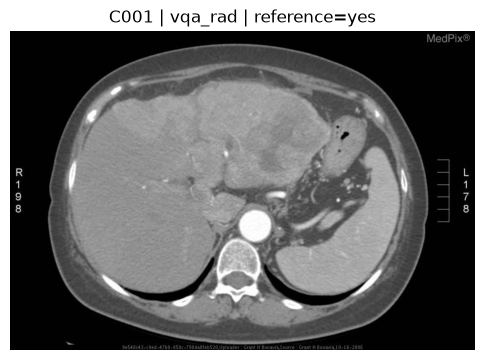

Question: is there contrast used in the above image?
Source answer: yes
Phase: pilot | smoke test: True


In [22]:
def show_case(case_id):
    df = pd.read_csv(casebook_path, keep_default_na=False)
    row = df[df.case_id.eq(case_id)].iloc[0]
    img = Image.open(ROOT / row.image_path)
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"{row.case_id} | {row.dataset} | reference={row.reference_answer}")
    plt.show()
    print('Question:', row.question_en)
    print('Source answer:', row.reference_answer)
    print('Phase:', row.phase, '| smoke test:', row.smoke_test)

show_case('C001')

## 6. Freeze validation
After manual review, set `include_after_review=yes`, `review_status=approved`, and complete all six language fields for approved cases. This cell creates immutable pilot and evaluation files plus SHA-256 hashes. If any field is missing, it stops with a readable error.

In [23]:
REQUIRED = ['question_en','question_id','question_ms',
            'proposition_en','proposition_id','proposition_ms',
            'reference_answer','image_path','reviewer_initials']

reviewed = pd.read_csv(casebook_path, keep_default_na=False)
approved = reviewed[(reviewed.include_after_review.str.lower() == 'yes') &
                    (reviewed.review_status.str.lower() == 'approved')].copy()
missing = approved[REQUIRED].apply(lambda s: s.astype(str).str.strip().eq('')).any(axis=1)
if missing.any():
    display(approved.loc[missing, ['case_id'] + REQUIRED])
    raise ValueError('Approved cases still contain required blank fields.')

expected = {'pilot': 10, 'evaluation_vqa_rad': 100, 'evaluation_slake': 25}
counts = {
    'pilot': len(approved[approved.phase.eq('pilot')]),
    'evaluation_vqa_rad': len(approved[approved.phase.eq('evaluation') & approved.dataset.eq('vqa_rad')]),
    'evaluation_slake': len(approved[approved.phase.eq('evaluation') & approved.dataset.eq('slake')]),
}
print('Approved counts:', counts)

def freeze_csv(df, filename):
    path = ROOT / 'casebooks' / filename
    df.to_csv(path, index=False)
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    (path.with_suffix(path.suffix + '.sha256')).write_text(digest + '  ' + path.name + '\n')
    print(filename, digest)

pilot_approved = approved[approved.phase.eq('pilot')].copy()
if len(pilot_approved) == expected['pilot']:
    freeze_csv(pilot_approved, 'pilot_cases_frozen.csv')
    print('Pilot casebook frozen. The smoke test and pilot may now be run.')
else:
    print(f"Pilot not frozen: approve exactly {expected['pilot']} pilot cases; currently {len(pilot_approved)}.")

eval_approved = approved[approved.phase.eq('evaluation')].copy()
eval_ready = (counts['evaluation_vqa_rad'] == expected['evaluation_vqa_rad'] and
              counts['evaluation_slake'] == expected['evaluation_slake'])
if eval_ready:
    freeze_csv(eval_approved, 'evaluation_cases_frozen.csv')
    print('Evaluation casebook frozen. The 125-case study may now be run.')
else:
    print('Evaluation not frozen yet; this is normal while preparing the pilot.')

Approved counts: {'pilot': 10, 'evaluation_vqa_rad': 0, 'evaluation_slake': 0}
pilot_cases_frozen.csv a87892688513f68416d29322ab835eab26aa184eaa3906655b6cbc8d95de3981
Pilot casebook frozen. The smoke test and pilot may now be run.
Evaluation not frozen yet; this is normal while preparing the pilot.


## Next notebook
The inference notebook will consume only the frozen CSV files. It will run the 2-case smoke subset, then the full 10-case pilot, and finally require an explicit protocol-freeze flag before allowing the 125-case evaluation. Each completed trial will be appended atomically to model-specific checkpoint files.